# Project 3B T126 - Water Pipe Failure Prediction

This notebook provides a short end-to-end demonstration of the final project workflow.

Detailed exploratory work, preprocessing logic, modelling functions, and evaluation utilities are stored in separate `.py` files under `src/` folder.

## 1. Dataset Review and Final Selection

Several candidate datasets were reviewed before selecting the final modelling dataset.

### 1.1 Dataset shortlist summary

| Dataset | Reviewed by | Outcome |
|---|---|---|
| Melbourne Water Mains + Soil | Shival | Useful for later adaptation, but no historical failure labels for direct supervised modelling |
| Bozeman | Joe | Small dataset with limited records, not strong enough as the main modelling dataset |
| Netherlands reference data | Anh | Useful as reference material, but less suitable for our current flat ML workflow |
| Kitchener Water Mains + Breaks | Anh | Selected as the final modelling dataset because it includes both pipe asset data and historical break records, even though does not include soil or environmental factors |
| External Canadian soil datasets | Anh | Tested as supporting data, but not used as main modelling features |

### 1.2 Final dataset decision

The **Kitchener dataset** was selected as the final modelling dataset because it provides:

- water main asset information
- historical break records
- usable matching between break records and pipe assets
- enough structure to create a pipe-level supervised learning dataset

### 1.3 External soil dataset result

Two external Canadian soil datasets were tested using spatial joins:

1. Ontario Soil Survey Complex  
2. CANSIS / Soil Landscapes of Canada

Both spatial joins worked technically, but the soil attributes were too broad or too dominated by general urban / regional categories. They did not add strong pipe-level detail for modelling.

## 2. Kitchener Preprocessing Workflow

This section demonstrates the final preprocessing pipeline used to convert the raw Kitchener mains and break datasets into a clean pipe-level dataset for modelling.

**Preprocessing steps**

- cleans the raw mains and break source tables
- removes weak or high-missing fields
- standardises date and key fields
- links break records to water main assets
- aggregates event-level break history to pipe level
- creates the target variable `has_break`
- derives final modelling features such as `pipe_age`
- exports the final model-ready dataset

**Main output**

The main file used for modelling is:

- `data/processed/kitchener_model_ready.csv`

### 2.1 Run pre-processing

In [5]:
from src.kitchener_preprocessing import (
    run_kitchener_preprocessing,
    plot_target_distribution
)

kitchener_results = run_kitchener_preprocessing(
    mains_path="data/raw/Kitchener/Kitchener_watermains.csv",
    breaks_path="data/raw/Kitchener/Kitchener_watermainbreaks.csv",
    output_dir="data/processed",
    verbose=True
)

/Users/anhntrinh/Documents/GitHub/MOP-Code/Playground/Project_3B_T126/src/kitchener_preprocessing.py:83: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  breaks_clean[col] = pd.to_datetime(breaks_clean[col], errors="coerce")
/Users/anhntrinh/Documents/GitHub/MOP-Code/Playground/Project_3B_T126/src/kitchener_preprocessing.py:83: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  breaks_clean[col] = pd.to_datetime(breaks_clean[col], errors="coerce")
/Users/anhntrinh/Documents/GitHub/MOP-Code/Playground/Project_3B_T126/src/kitchener_preprocessing.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please speci

Raw mains shape: (16163, 27)
Raw breaks shape: (2994, 37)
Cleaned mains shape: (16163, 22)
Cleaned breaks shape: (2994, 18)
Asset match summary: {'asset_match_rate_pct': 81.9, 'matched_break_rows': 2452, 'unmatched_break_rows': 542}
MAIN breaks shape: (2922, 18)
Matched MAIN breaks shape: (2451, 18)
Pipe-level dataset shape: (16163, 26)
Model-ready dataset shape: (16163, 20)

Target distribution:
has_break
0    14929
1     1234
Name: count, dtype: int64

Saved outputs:
- breaks_clean: data/processed/kitchener_breaks_clean.csv
- mains_clean: data/processed/kitchener_mains_clean.csv
- pipe_level: data/processed/kitchener_pipe_level.csv
- pipe_master: data/processed/kitchener_pipe_master.csv
- model_ready: data/processed/kitchener_model_ready.csv


### 2.2 Preview model-ready data

In [7]:
model_ready_df = kitchener_results["model_ready_df"]
display(model_ready_df.head())

,pressure_zone,category,pipe_size,material,lined,lined_material,acquisition,ownership,bridge_main,criticality,rel_cleaning_area,rel_cleaning_subarea,undersized,shallow_main,condition_score,oversized,cleaned,shape__length,has_break,pipe_age
0,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,8.50,0,0,34.210563,0,47.2
1,KIT 4,TREATED,300,DI,0,NONE,PURCHASED,REGION,0,7.0,1,4,0,0,8.50,0,0,0.355118,0,57.7
2,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,7.0,6,8,0,0,6.10,0,1,67.852910,1,47.2
3,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,4.58,0,1,7.039328,1,47.2
4,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,8.50,0,1,14.956131,0,47.2


### 2.3 Check class balance

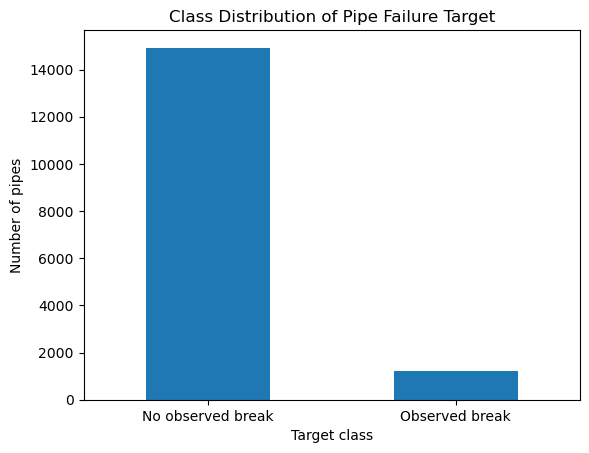

In [9]:
plot_target_distribution(kitchener_results["pipe_df"])

## 3. Kitchener - Model Development and Comparision

### 3.1 Random Forest Modelling

This section runs the Random Forest model on the processed Kitchener pipe-level dataset. It provides a baseline machine learning model to predict whether a pipe has an observed break.

## 4. Melbourne Water Main Data Preprocessing

This section prepares the raw Melbourne water main dataset for the Melbourne risk identification stage.

The preprocessing workflow includes:
- Selecting relevant asset-level columns from the raw dataset
- Cleaning missing and inconsistent values (e.g. invalid lengths, widths, future dates)
- Converting date fields to proper datetime format
- Engineering key features such as `PIPE_AGE`, `HAS_RELINED`, and `YEARS_SINCE_RELINED`
- Creating data quality flags (e.g. missing construction date, missing relined date)
- Standardising categorical fields and filling non-critical missing values
- Removing duplicate records

The output is a cleaned, pipe-level dataset ready for the finding adaptation stage.

In [12]:
from src.melbourne_preprocessing import build_melbourne_cleaned_dataset

melbourne_cleaned = build_melbourne_cleaned_dataset()

display(melbourne_cleaned.head())
print(melbourne_cleaned.shape)

/Users/anhntrinh/Documents/GitHub/MOP-Code/Playground/Project_3B_T126/src/melbourne_preprocessing.py:92: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melbourne[col] = pd.to_datetime(melbourne[col], errors="coerce")
/Users/anhntrinh/Documents/GitHub/MOP-Code/Playground/Project_3B_T126/src/melbourne_preprocessing.py:92: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melbourne[col] = pd.to_datetime(melbourne[col], errors="coerce")


,ASSET_ID,COMPKEY,UNITID,UNITID2,MAIN_NAME,MAIN_LINE_TYPE,MAIN_CLASS,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,...,HAS_RELINED,YEARS_SINCE_RELINED,MISSING_RELINED_DATE,INVALID_PIPE_LENGTH,INVALID_PIPE_WIDTH,FUTURE_RELINED_DATE,FIELD_TEAM,SERVICE_STATUS,COMMENTS,DATE_LAST_UPDATED
0,M474,296455,M474-00374BR,M474-00377BR,ST GEORGES RD REPLACEMENT MAIN,MAINBG,T,MSCL,2.72,1400.0,...,0,0.0,1,0,0,0,PRESTON,IN,NO COMMENT,2018-09-26 12:31:01
1,Z060,293331,WZ060-ZA,WZ060T101,CARDINIA CREEK MINI HYDRO,MAINAG,S,MSCL,1.88,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-03-01 14:04:45
2,M281,1017825,WZ060-01040BR,M281V-EB,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,1.74,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00
3,R144,234582,WR144V-R,WR144-0-0019,TYABB RESERVOIR,MAINBG,S,MS,131.30,100.0,...,0,0.0,1,0,0,0,WESTERNPORT,IN,STORAGE CLEANING PIPE,2018-07-23 12:11:24
4,M281,227935,M281V-EA,WZ060-01040BR,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,5.26,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00


(12677, 24)


### Melbourne Preprocessing Output Summary

The preprocessing pipeline produced a cleaned Melbourne dataset with **12,677 rows and 24 columns** after removing exact duplicate rows.

Most fields needed for finding adaptation are complete after cleaning, including material, pipe length, pipe width, relining indicators, service status, and operational context.

Some fields still contain missing values:
- `PIPE_AGE` / `DATE_OF_CONSTRUCTION`: 901 missing records
- `DATE_RELINED`: 7,537 missing records
- `DATE_LAST_UPDATED`: 53 missing records

These are acceptable for the next stage because missing construction and relining dates are captured using flags such as `MISSING_CONSTRUCTION_DATE` and `MISSING_RELINED_DATE`.

`COMPKEY` should be used as the main pipe/segment identifier because `ASSET_ID` is repeated across many records.

In [14]:
print("Shape:", melbourne_cleaned.shape)
print("\nMissing values:")
display(melbourne_cleaned.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", melbourne_cleaned.duplicated().sum())
print("Unique COMPKEY:", melbourne_cleaned["COMPKEY"].nunique())
print("Unique ASSET_ID:", melbourne_cleaned["ASSET_ID"].nunique())

Shape: (12677, 24)

Missing values:


DATE_RELINED                 7537
DATE_OF_CONSTRUCTION          901
PIPE_AGE                      901
DATE_LAST_UPDATED              53
COMMENTS                        0
SERVICE_STATUS                  0
FIELD_TEAM                      0
FUTURE_RELINED_DATE             0
INVALID_PIPE_WIDTH              0
INVALID_PIPE_LENGTH             0
MISSING_RELINED_DATE            0
YEARS_SINCE_RELINED             0
HAS_RELINED                     0
ASSET_ID                        0
COMPKEY                         0
PIPE_WIDTH                      0
PIPE_LENGTH                     0
MATERIAL                        0
MAIN_CLASS                      0
MAIN_LINE_TYPE                  0
MAIN_NAME                       0
UNITID2                         0
UNITID                          0
MISSING_CONSTRUCTION_DATE       0
dtype: int64


Duplicate rows: 0
Unique COMPKEY: 12631
Unique ASSET_ID: 248
